<div style="border-left: 5px solid #1f4e79; padding: 16px 20px; background-color: #f8fafc; border: 1px solid #d9e2ec; border-radius: 6px; margin-bottom: 24px; font-family: Arial, sans-serif;">
  <h1 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 28px;">Notebook 02 — Nettoyage progressif et filtrage résidentiel</h1>
  <p style="margin: 0; color: #4b5563; font-size: 15px; line-height: 1.55;">Ce notebook transforme la base DVF intermédiaire en socle résidentiel nettoyé, traçable et exploitable pour les analyses de prix au m². Objectif du notebook L’étape sécurise le périmètre d’analyse avant les enrichissements et la modélisation. Elle vérifie les variables économiques essentielles, isole les maisons et appartements, identifie les incohérences évidentes puis applique des bornes métier sur la valeur foncière, la surface et le prix au m². La logique retenue est volontairement progressive : chaque exclusion est mesurée afin d’éviter qu’un filtre technique ne masque une perte excessive ou un biais de marché.</p>
</div>

In [1]:
# Charger les bibliothèques nécessaires
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display

# Configuration : ignorer les avertissements, thème des graphiques, affichage des colonnes
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)

In [ ]:
# Localisation du projet et des fichiers intermédiaires.

# Les données utilisées proviennent du notebook précédent
# et correspondent à la base DVF enrichie au niveau mutation.

CURRENT_DIR = Path.cwd().resolve()

PROJECT_ROOT = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name.lower() == "notebooks"
    else CURRENT_DIR
)

DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

INPUT_PATH = DATA_PROCESSED_DIR / "df_dvf_base_eco_intermediaire.parquet"
OUTPUT_PATH = DATA_PROCESSED_DIR / "df_mutations_residentielles_nettoyees.parquet"

# Vérification de la présence du fichier d'entrée.
if not INPUT_PATH.exists():
    raise FileNotFoundError(
        "Fichier d'entrée introuvable : "
        f"{INPUT_PATH}\n"
        "Le fichier attendu doit être produit par le notebook "
        "01_import_et_exploration_dvf."
    )

# Chargement des données préparées en amont.
df = pd.read_parquet(INPUT_PATH)

# Contrôle rapide du chargement.
print("Racine projet :", PROJECT_ROOT)
print("Fichier chargé :", INPUT_PATH)

display(df.head(3))

print("Dimensions :", df.shape)

Racine projet : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE
Fichier chargé : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_dvf_base_eco_intermediaire.parquet


,id_mutation,date_mutation,numero_disposition,nature_mutation,valeur_fonciere,code_commune,nom_commune,code_departement,longitude,latitude,nb_lignes,nb_locaux,nb_appartements,nb_maisons,nb_dependances,surface_bati_totale,surface_terrain_totale,nb_pieces_total,nombre_lots_total,surface_carrez_totale,has_bati,has_terrain,has_imm_special,nb_seg_terrain_a_batir,nb_seg_agricole,nb_seg_agrement,nb_seg_bois_landes,nb_seg_sols,nb_seg_autre,nb_logements,has_logement,has_dependance,mutation_simple_logement,mutation_multiple_logements,ratio_bati_terrain_mutation,type_marche_mutation,type_mutation_economique,avec_dependances,categorie_logement,sous_categorie_logement,type_bien,surface_reference,source_surface_reference,surface_terrain_reference,prix_m2,prix_par_piece,ratio_bati_terrain,flag_valeur_valide,flag_surface_reference_valide,flag_prix_m2_valide,flag_qualite_globale
0,2021-1,2021-01-05,1,Vente,185000.0,1426,Val-Revermont,1,5.386107,46.327101,2,2,0,1,1,97.0,4820.0,5.0,0,NaN,True,True,False,0,0,0,0,2,0,1,True,True,True,False,0.020124,marche_secondaire_residentiel,maison,True,Maison,Maison moyenne (80-120 m²),Maison,97.00,bati,4820.0,1907.216495,37000.0,0.020124,True,True,True,True
1,2021-10,2021-01-08,1,Vente,185000.0,1289,Péronnas,1,5.210182,46.187705,1,1,0,1,0,100.0,703.0,4.0,0,NaN,True,True,False,0,0,0,0,1,0,1,True,False,True,False,0.142248,marche_secondaire_residentiel,maison,False,Maison,Maison moyenne (80-120 m²),Maison,100.00,bati,703.0,1850.000000,46250.0,0.142248,True,True,True,True
2,2021-1000,2021-04-01,1,Vente,72150.0,1053,Bourg-en-Bresse,1,5.228652,46.213258,2,2,1,0,1,86.0,NaN,4.0,4,174.48,True,False,False,0,0,0,0,0,2,1,True,True,True,False,NaN,marche_secondaire_residentiel,appartement,True,Appartement,Appartement T4,Appartement,174.48,carrez,NaN,413.514443,18037.5,NaN,True,True,True,True


Dimensions : (4019581, 51)


In [3]:
# Vérifier la disponibilité des colonnes clés
# Lister les variables qu'on cherche
key_vars = ["valeur_fonciere", "surface_reference", "type_mutation_economique", "prix_m2"]
available = [c for c in key_vars if c in df.columns]
missing = [c for c in key_vars if c not in df.columns]

print("Colonnes présentes:", df.shape[1])
print("Variables cles présentes:", available)
print("Variables cles manquantes:", missing if missing else "Aucune")

display(
    pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "na_rate": df.isna().mean().round(4),
        }
    ).loc[available].sort_index() if available else pd.DataFrame()
 )

Colonnes présentes: 51
Variables cles présentes: ['valeur_fonciere', 'surface_reference', 'type_mutation_economique', 'prix_m2']
Variables cles manquantes: Aucune


,dtype,na_rate
prix_m2,float64,0.0006
surface_reference,float64,0.0000
type_mutation_economique,object,0.0000
valeur_fonciere,float64,0.0006


In [5]:
# Créer le filtre résidentiel : garder seulement Maison et Appartement
if "type_bien" not in df.columns:
    raise KeyError("La colonne 'type_bien' est necessaire pour definir le perimetre residentiel.")

# Définir les types de bien résidentiel
residentiel_types = {"Maison", "Appartement"}
df["flag_residentiel"] = df["type_bien"].isin(residentiel_types)

volume_all = len(df)
volume_res = int(df["flag_residentiel"].sum())

print(f"Volume total: {volume_all:,}")
print(f"Volume residentiel (Maison/Appartement): {volume_res:,}")
print(f"Part residentielle: {volume_res / volume_all:.2%}")

display(
    df["type_bien"].fillna("<NA>").value_counts(dropna=False).rename_axis("type_bien").to_frame("n")
)

Volume total: 4,019,581
Volume residentiel (Maison/Appartement): 4,019,581
Part residentielle: 100.00%


,n
type_bien,
Maison,2117308
Appartement,1902273


In [6]:
# Vérification du type de marché : distribution et cohérence
market_col = "type_marche_mutation"

if market_col in df.columns:
    # Compter les observations par modalité de marché
    market_dist = (
        df[market_col]
        .value_counts(dropna=False)
        .rename_axis(market_col)
        .reset_index(name="n")
    )
    # Ajouter la part en pourcentage
    market_dist["part"] = market_dist["n"] / len(df)
    display(market_dist)

    # Vérifier la présence d'une modalité résidentielle
    if "résidentiel" in market_dist[market_col].astype(str).str.lower().str.cat(sep=" "):
        print("Contrôle : une modalité résidentielle est bien repérée dans type_marche_mutation.")
    else:
        print("Alerte douce : aucune modalité explicitement résidentielle n'est détectée dans type_marche_mutation.")
else:
    print("Information : la colonne type_marche_mutation n'est pas disponible dans cette version de la base.")

# Vérifier que la part résidentielle est suffisante (au moins 50%)
if volume_all > 0 and volume_res / volume_all < 0.50:
    print("Alerte : la part résidentielle est inférieure à 50 %. Vérifier le périmètre et le typage de type_bien.")
else:
    print("Contrôle périmètre : la part résidentielle est cohérente avec l'objectif du notebook.")

,type_marche_mutation,n,part
0,marche_secondaire_residentiel,4019581,1.0


Alerte douce : aucune modalité explicitement résidentielle n'est détectée dans type_marche_mutation.
Contrôle périmètre : la part résidentielle est cohérente avec l'objectif du notebook.


In [ ]:
# Créer une sous-base résidentielle pour l'analyse et cration de flags de qualite sur les trois variables critiques: Surface, valeur foncière et prix au m²
df_res = df[df["flag_residentiel"]].copy()

# Vérifier la présence des colonnes clés
for col in ["surface_reference", "valeur_fonciere", "prix_m2"]:
    if col not in df_res.columns:
        df_res[col] = np.nan

# Créer des flags pour les valeurs non-positives
df_res["flag_surface_non_positive"] = df_res["surface_reference"].fillna(-1) <= 0
df_res["flag_valeur_non_positive"] = df_res["valeur_fonciere"].fillna(-1) <= 0
df_res["flag_prix_m2_non_positif"] = df_res["prix_m2"].fillna(-1) <= 0

# Recalculer le prix au m² pour vérifier la cohérence
df_res["prix_m2_calcule"] = np.where(
    (df_res["surface_reference"] > 0) & (df_res["valeur_fonciere"] > 0),
    df_res["valeur_fonciere"] / df_res["surface_reference"],
    np.nan,
 )

# Vérifier l'écart entre prix observé et prix recalculé
ecart_relatif = (df_res["prix_m2"] - df_res["prix_m2_calcule"]).abs() / df_res["prix_m2_calcule"]
df_res["flag_prix_m2_incoherent"] = ecart_relatif > 0.20
df_res.loc[df_res["prix_m2_calcule"].isna(), "flag_prix_m2_incoherent"] = True

flag_cols = [
    "flag_surface_non_positive",
    "flag_valeur_non_positive",
    "flag_prix_m2_non_positif",
    "flag_prix_m2_incoherent",
]

display(
    pd.DataFrame(
        {
            "nb": [int(df_res[c].sum()) for c in flag_cols],
            "part": [float(df_res[c].mean()) for c in flag_cols],
        },
        index=flag_cols,
    ).sort_values("part", ascending=False)
 )

,nb,part
flag_prix_m2_non_positif,2477,0.000616
flag_prix_m2_incoherent,2477,0.000616
flag_valeur_non_positive,2282,0.000568
flag_surface_non_positive,196,0.000049


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Diagnostic économique avant nettoyage</h3>
  <div style="color: #4b5563; font-size: 14px;">Les distributions sont examinées avant toute exclusion afin de distinguer les erreurs manifestes, les biens atypiques et les queues de distribution plausibles. Cette lecture préalable évite de choisir des seuils sans compréhension du marché.</div>
</div>

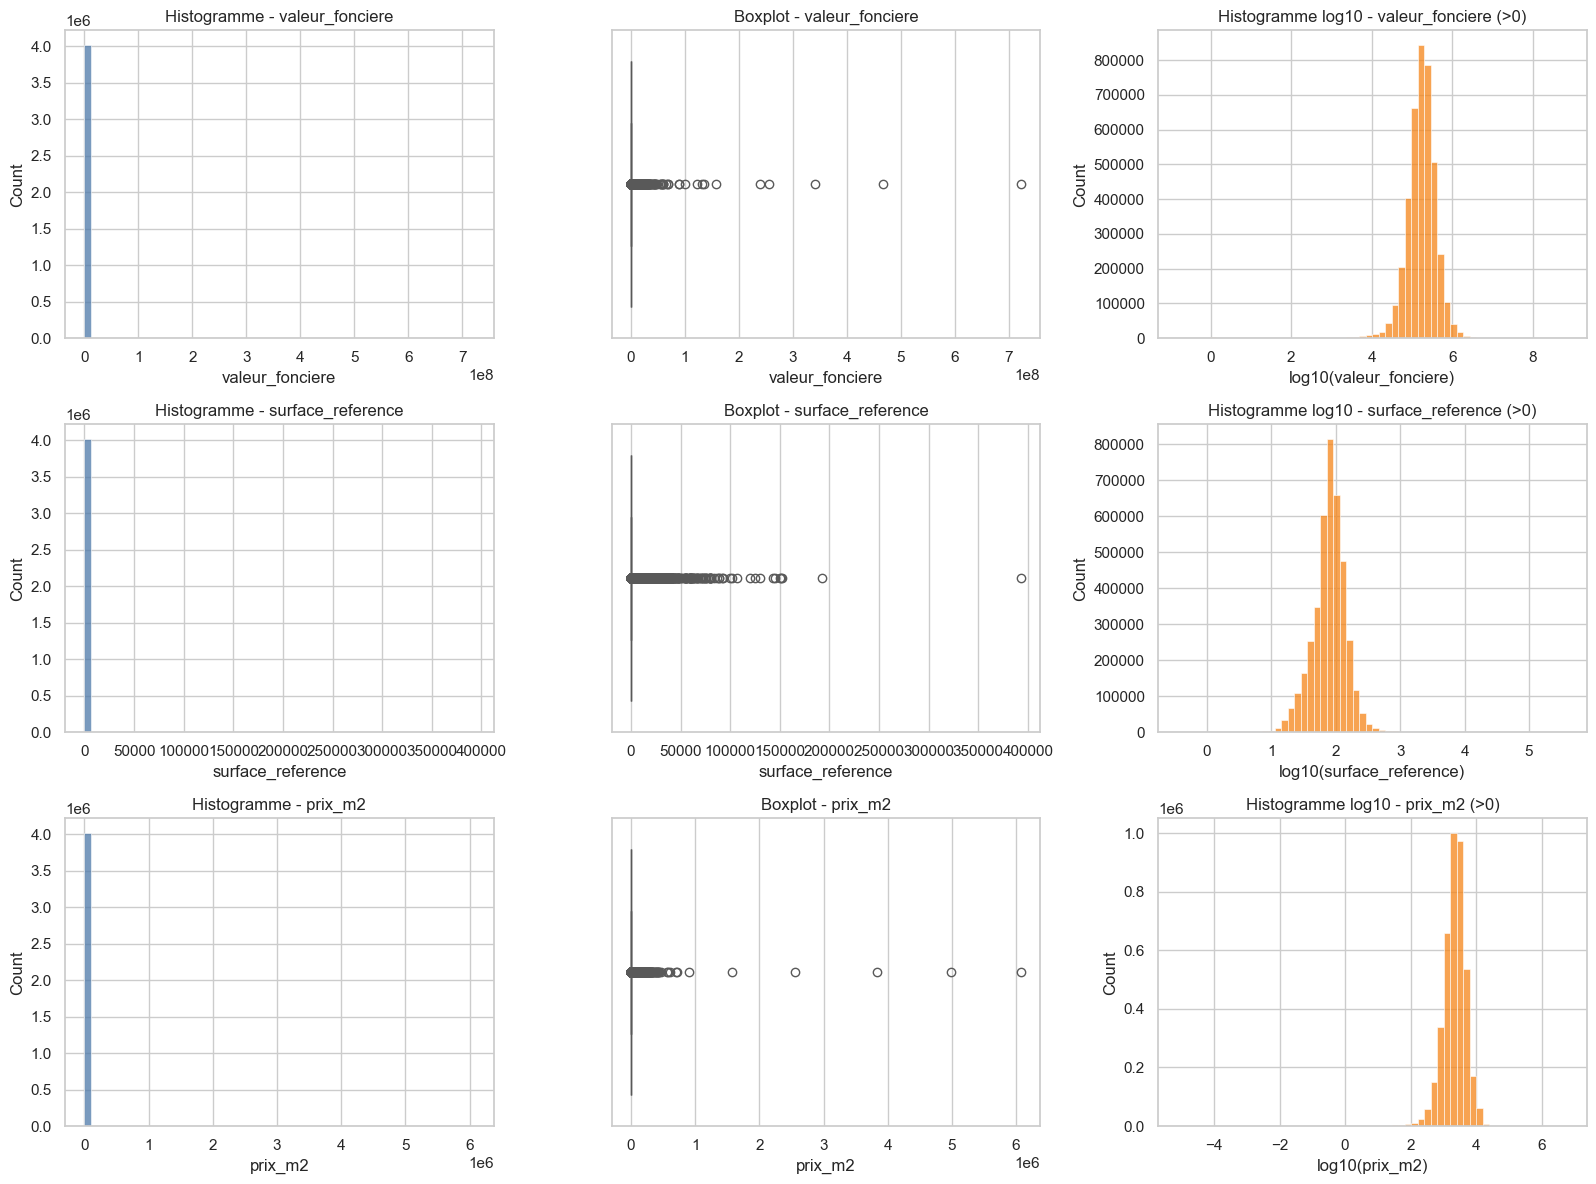

In [ ]:
# Affichage des distributions des variables clés avant nettoyage
num_cols = [c for c in ["valeur_fonciere", "surface_reference", "prix_m2"] if c in df_res.columns]

if not num_cols:
    print("Aucune variable numerique cible disponible pour les distributions.")
else:
    # Créer une figure avec 3 colonnes par variable (histogramme, boîte, log)
    fig, axes = plt.subplots(len(num_cols), 3, figsize=(16, 4 * len(num_cols)))
    if len(num_cols) == 1:
        axes = np.array([axes])

    for i, col in enumerate(num_cols):
        s = df_res[col].dropna()

        # Histogramme simple
        sns.histplot(s, bins=60, ax=axes[i, 0], color="#4C78A8")
        axes[i, 0].set_title(f"Histogramme - {col}")

        # Boîte à moustaches
        sns.boxplot(x=s, ax=axes[i, 1], color="#72B7B2")
        axes[i, 1].set_title(f"Boxplot - {col}")

        # Histogramme en log
        s_pos = s[s > 0]
        sns.histplot(np.log10(s_pos), bins=60, ax=axes[i, 2], color="#F58518")
        axes[i, 2].set_title(f"Histogramme log10 - {col} (>0)")
        axes[i, 2].set_xlabel(f"log10({col})")

    plt.tight_layout()
    plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des distributions avant nettoyage</h3>
  <div style="color: #4b5563; font-size: 14px;">Les graphiques confirment une forte asymétrie des valeurs immobilières : les prix, surfaces et valeurs foncières sont concentrés sur un cœur de marché, mais avec des queues longues. L’échelle logarithmique améliore la lisibilité et montre que certaines valeurs extrêmes peuvent déformer les analyses si elles ne sont pas encadrées.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Gestion des valeurs extrêmes</h3>
  <div style="color: #4b5563; font-size: 14px;">Les bornes combinent une logique métier et une logique de robustesse statistique. Les observations sont d’abord marquées par des flags afin de mesurer l’impact des seuils avant suppression définitive.</div>
</div>

In [9]:
# Définir les bornes de nettoyage pour chaque variable
bounds = {
    "valeur_fonciere": (20_000, 5_000_000),
    "surface_reference": (9, 500),
    "prix_m2": (300, 45_000),
}

# Créer un flag pour chaque variable qui sort de ses bornes
for col, (low, high) in bounds.items():
    if col not in df_res.columns:
        continue
    df_res[f"flag_outlier_{col}"] = (~df_res[col].between(low, high)) | (df_res[col].isna())

# Synthétiser : une ligne est outlier si elle dépasse une borne
outlier_cols = [c for c in df_res.columns if c.startswith("flag_outlier_")]
df_res["flag_outlier"] = df_res[outlier_cols].any(axis=1) if outlier_cols else False

print("Part de lignes avec au moins un outlier:", f"{df_res['flag_outlier'].mean():.2%}")

if outlier_cols:
    display(
        pd.DataFrame(
            {
                "nb": [int(df_res[c].sum()) for c in outlier_cols],
                "part": [float(df_res[c].mean()) for c in outlier_cols],
            },
            index=outlier_cols,
        ).sort_values("part", ascending=False)
    )

preview_cols = [c for c in ["type_bien", "valeur_fonciere", "surface_reference", "prix_m2"] if c in df_res.columns]
display(df_res.loc[df_res["flag_outlier"], preview_cols].head(10))

Part de lignes avec au moins un outlier: 2.34%


,nb,part
flag_outlier_prix_m2,71411,0.017766
flag_outlier_valeur_fonciere,51607,0.012839
flag_outlier_surface_reference,16843,0.004190


,type_bien,valeur_fonciere,surface_reference,prix_m2
18,Maison,43000.0,484.00,88.842975
40,Maison,35000.0,185.00,189.189189
41,Maison,35000.0,133.00,263.157895
50,Maison,57000.0,314.00,181.528662
54,Maison,7500.0,45.00,166.666667
98,Maison,31100.0,106.00,293.396226
100,Maison,25000.0,115.00,217.391304
101,Appartement,17500.0,163.00,107.361963
117,Appartement,30000.0,102.44,292.854354
196,Maison,600000.0,1425.00,421.052632


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture de l’impact des seuils</h3>
  <div style="color: #4b5563; font-size: 14px;">Au moins un outlier est détecté sur environ 2,34 % des lignes. Le prix au m² est le filtre le plus fréquent, devant la valeur foncière et la surface. L’impact est plus marqué sur les maisons que sur les appartements, ce qui est cohérent avec la plus grande diversité des surfaces et des configurations foncières côté maisons.</div>
</div>

In [ ]:
#Documentation des seuils
# Analyse des seuils utilisés
threshold_docs = []

# Justifications métier pour chaque borne
justifications_metier = {
    "valeur_fonciere": "Écarter les mutations à valeur très faible ou très élevée, souvent peu représentatives d'un marché résidentiel standard.",
    "surface_reference": "Une surface inférieure à 9 m² correspond rarement à un logement principal classique ; 500 m² limite les biens très atypiques.",
    "prix_m2": "Écarter les prix au m² très faibles ou très élevés afin de stabiliser l'analyse résidentielle.",
}

for col, (low, high) in bounds.items():
    if col not in df_res.columns:
        continue

    # Calculer les quantiles et l'écart interquartile (IQR)
    s = df_res[col].dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    iqr = q3 - q1
    iqr_low = q1 - 1.5 * iqr
    iqr_high = q3 + 1.5 * iqr

    # Compter les lignes qui sortent des bornes
    mask_exclue = ~df_res[col].between(low, high) | df_res[col].isna()

    threshold_docs.append({
        "variable": col,
        "seuil_bas": low,
        "seuil_haut": high,
        "q01": s.quantile(0.01),
        "q99": s.quantile(0.99),
        "borne_iqr_basse": iqr_low,
        "borne_iqr_haute": iqr_high,
        "nb_exclus": int(mask_exclue.sum()),
        "part_exclue": float(mask_exclue.mean()),
        "justification_métier": justifications_metier.get(col, "Seuil de cohérence métier."),
    })

threshold_summary = pd.DataFrame(threshold_docs)
display(threshold_summary)

# Impact des seuils par type de bien.
if "type_bien" in df_res.columns and outlier_cols:
    impact_outliers_type = (
        df_res.assign(flag_outlier_total=df_res[outlier_cols].any(axis=1))
        .groupby("type_bien")
        .agg(
            nb_lignes=("type_bien", "size"),
            nb_outliers=("flag_outlier_total", "sum"),
        )
        .reset_index()
    )
    impact_outliers_type["part_outliers"] = impact_outliers_type["nb_outliers"] / impact_outliers_type["nb_lignes"]
    display(impact_outliers_type)

,variable,seuil_bas,seuil_haut,q01,q99,borne_iqr_basse,borne_iqr_haute,nb_exclus,part_exclue,justification_métier
0,valeur_fonciere,20000,5000000,16000.000000,1.150000e+06,-148000.00000,540000.000000,51607,0.012839,Écarter les mutations à valeur très faible ou ...
1,surface_reference,9,500,17.690000,3.200000e+02,-26.00000,198.000000,16843,0.004190,Une surface inférieure à 9 m² correspond rarem...
2,prix_m2,300,45000,204.081633,1.166667e+04,-1911.72512,6935.652958,71411,0.017766,Écarter les prix au m² très faibles ou très él...


,type_bien,nb_lignes,nb_outliers,part_outliers
0,Appartement,1902273,35428,0.018624
1,Maison,2117308,58803,0.027773


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Nettoyage progressif et mesure des pertes</h3>
  <div style="color: #4b5563; font-size: 14px;">Le nettoyage est appliqué par étapes afin de mesurer précisément l’effet de chaque filtre : périmètre résidentiel, incohérences évidentes, puis outliers métier. Cette approche rend le résultat reproductible et évite un nettoyage opaque. Approche progressive du nettoyage des données DVF Le nettoyage des données DVF est réalisé de manière progressive en s’appuyant prioritairement sur des normes métiers immobilières plutôt que sur des standards statistiques génériques de data science. Dans le contexte immobilier, certaines valeurs extrêmes ne constituent pas nécessairement des anomalies mais peuvent refléter des réalités de marché spécifiques : biens de prestige, foncier atypique, dépendances, locaux mixtes ou transactions complexes. Une suppression trop agressive des outliers risquerait donc d’altérer la représentativité économique des données. L’objectif est ainsi de distinguer : les erreurs manifestes de saisie ou d’intégration, les valeurs atypiques mais économiquement plausibles, les cas particuliers relevant de segments de marché spécifiques. La gestion des valeurs manquantes (`NaN`) suit la même logique métier. Un `NaN` ne signifie pas systématiquement une donnée erronée : il peut traduire une information non renseignée, une variable non applicable au bien concerné, une absence de disponibilité dans la source d’origine, ou un choix administratif de non-collecte. Par conséquent, les traitements appliqués aux valeurs manquantes sont différenciés selon la nature de la variable et son rôle analytique, afin de préserver au maximum la cohérence économique et territoriale du jeu de données. Cette approche progressive permet de limiter les biais de nettoyage, de conserver la diversité structurelle du marché immobilier et de préparer des données plus robustes pour les phases ultérieures d’analyse et de modélisation.</div>
</div>

In [ ]:
# Nettoyage de la base par étapes en suivant l'impact
df_work = df.copy()
steps = []

def track_step(name, before, after):
    # Enregistrer le volume et le taux de conservation à chaque étape
    steps.append(
        {
            "step": name,
            "n_before": int(before),
            "n_after": int(after),
            "taux_conserve": round(after / before, 4) if before else np.nan,
        }
    )

# Étape 1 : garder seulement le résidentiel
before = len(df_work)
df_work = df_work[df_work["flag_residentiel"]].copy()
track_step("perimetre_residentiel", before, len(df_work))

# Étape 2 : préparer les flags d'incohérence
for col in ["surface_reference", "valeur_fonciere", "prix_m2"]:
    if col not in df_work.columns:
        df_work[col] = np.nan

df_work["flag_surface_non_positive"] = df_work["surface_reference"].fillna(-1) <= 0
df_work["flag_valeur_non_positive"] = df_work["valeur_fonciere"].fillna(-1) <= 0
df_work["flag_prix_m2_non_positif"] = df_work["prix_m2"].fillna(-1) <= 0

# Étape 3 : exclure les vraies absurdités (zéro ou négatif)
before = len(df_work)
mask_clear_bad = (
    df_work["flag_surface_non_positive"]
    | df_work["flag_valeur_non_positive"]
    | df_work["flag_prix_m2_non_positif"]
)
df_work = df_work[~mask_clear_bad].copy()
track_step("exclusion_incoherences_claires", before, len(df_work))

# Étape 4 : exclure les valeurs extrêmes (outliers)
for col, (low, high) in bounds.items():
    if col in df_work.columns:
        df_work[f"flag_outlier_{col}"] = ~df_work[col].between(low, high)

outlier_cols_work = [c for c in df_work.columns if c.startswith("flag_outlier_")]
df_work["flag_outlier"] = df_work[outlier_cols_work].any(axis=1) if outlier_cols_work else False

before = len(df_work)
df_clean = df_work[~df_work["flag_outlier"]].copy()
track_step("exclusion_outliers_simples", before, len(df_clean))

impact_df = pd.DataFrame(steps)
display(impact_df)
print("Dimensions finales:", df_clean.shape)

,step,n_before,n_after,taux_conserve
0,perimetre_residentiel,4019581,4019581,1.0000
1,exclusion_incoherences_claires,4019581,4017104,0.9994
2,exclusion_outliers_simples,4017104,3925350,0.9772


Dimensions finales: (3925350, 59)


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture du volume final</h3>
  <div style="color: #4b5563; font-size: 14px;">Le périmètre résidentiel ne retire aucune ligne, ce qui confirme que la base d’entrée est déjà ciblée. Les incohérences évidentes retirent 2 477 lignes, puis les outliers métier ramènent le volume final à 3 925 350 mutations, soit environ 97,66 % du volume initial conservé.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse des lignes supprimées et visualisations avant / après</h3>
  <div style="color: #4b5563; font-size: 14px;">La suppression d’observations doit être contrôlée : l’objectif est de vérifier que le nettoyage retire bien des cas problématiques sans effacer une structure entière du marché. Cette section analyse donc les motifs d’exclusion puis compare les distributions avant et après filtrage.</div>
</div>

In [ ]:
# AnalyserAnalyse des lignes supprimées : groupement par motif
deleted_frames = []

# Groupe 1 : non résidentiel
deleted_non_res = df.loc[~df["flag_residentiel"]].copy()
deleted_non_res["motif_suppression"] = "hors_périmètre_résidentiel"
deleted_frames.append(deleted_non_res)

# Groupe 2 : valeurs clairement aberrantes
df_tmp_res = df.loc[df["flag_residentiel"]].copy()
for col in ["surface_reference", "valeur_fonciere", "prix_m2"]:
    if col not in df_tmp_res.columns:
        df_tmp_res[col] = np.nan

mask_bad_tmp = (
    (df_tmp_res["surface_reference"].fillna(-1) <= 0)
    | (df_tmp_res["valeur_fonciere"].fillna(-1) <= 0)
    | (df_tmp_res["prix_m2"].fillna(-1) <= 0)
)
deleted_bad = df_tmp_res.loc[mask_bad_tmp].copy()
deleted_bad["motif_suppression"] = "incohérence_surface_valeur_prix"
deleted_frames.append(deleted_bad)

# Groupe 3 : outliers au-delà des bornes
df_tmp_ok = df_tmp_res.loc[~mask_bad_tmp].copy()
mask_out_tmp = pd.Series(False, index=df_tmp_ok.index)
for col, (low, high) in bounds.items():
    if col in df_tmp_ok.columns:
        mask_out_tmp = mask_out_tmp | (~df_tmp_ok[col].between(low, high))

deleted_out = df_tmp_ok.loc[mask_out_tmp].copy()
deleted_out["motif_suppression"] = "outlier_seuil_métier"
deleted_frames.append(deleted_out)

df_deleted = pd.concat(deleted_frames, axis=0, ignore_index=False)

suppression_summary = (
    df_deleted["motif_suppression"]
    .value_counts(dropna=False)
    .rename_axis("motif_suppression")
    .reset_index(name="nb_lignes")
)
suppression_summary["part_du_total_initial"] = suppression_summary["nb_lignes"] / len(df)
display(suppression_summary)

cols_deleted_desc = [c for c in ["prix_m2", "surface_reference", "valeur_fonciere"] if c in df_deleted.columns]
if cols_deleted_desc:
    display(df_deleted.groupby("motif_suppression")[cols_deleted_desc].describe().round(2))

if "type_bien" in df_deleted.columns:
    display(pd.crosstab(df_deleted["motif_suppression"], df_deleted["type_bien"], margins=True))

geo_col = "code_departement" if "code_departement" in df_deleted.columns else None
if geo_col:
    display(
        df_deleted.groupby(["motif_suppression", geo_col])
        .size()
        .rename("nb_lignes")
        .reset_index()
        .sort_values("nb_lignes", ascending=False)
        .head(20)
    )

,motif_suppression,nb_lignes,part_du_total_initial
0,outlier_seuil_métier,91754,0.022827
1,incohérence_surface_valeur_prix,2477,0.000616


prix_m2                                 \
                                   count     mean       std  min    25%   
motif_suppression                                                         
incohérence_surface_valeur_prix      0.0      NaN       NaN  NaN    NaN   
outlier_seuil_métier             91754.0  1630.71  32760.56  0.0  125.0   

                                                            surface_reference  \
                                    50%     75%         max             count   
motif_suppression                                                               
incohérence_surface_valeur_prix     NaN     NaN         NaN            2281.0   
outlier_seuil_métier             225.79  302.33  6072185.04           91754.0   

                                                                            \
                                   mean      std   min   25%   50%     75%   
motif_suppression                                                            
incohérence_surface_valeur_prix  303.98  2523.15  1.00  60.0  82.0  116.00   
outlier_seuil_métier             443.29  3150.10  0.35  52.0  99.0  209.33   

                                          valeur_fonciere             \
                                      max           count       mean   
motif_suppression                                                      
incohérence_surface_valeur_prix   66642.0           195.0  188200.62   
outlier_seuil_métier             392785.0         91754.0  316075.57   

                                                                      \
                                        std   min      25%       50%   
motif_suppression                                                      
incohérence_surface_valeur_prix   539691.77  1.00  64368.0  112500.0   
outlier_seuil_métier             3744334.50  0.15  10000.0   18500.0   

                                                         
                                       75%          max  
motif_suppression                                        
incohérence_surface_valeur_prix  186082.14    7217378.0  
outlier_seuil_métier              47500.00  722590020.0

type_bien,Appartement,Maison,All
motif_suppression,,,
incohérence_surface_valeur_prix,821,1656,2477
outlier_seuil_métier,34607,57147,91754
All,35428,58803,94231


,motif_suppression,code_departement,nb_lignes
167,outlier_seuil_métier,75,6414
134,outlier_seuil_métier,42,2083
120,outlier_seuil_métier,3,2074
151,outlier_seuil_métier,59,2028
150,outlier_seuil_métier,58,1948
156,outlier_seuil_métier,63,1921
181,outlier_seuil_métier,88,1900
163,outlier_seuil_métier,71,1752
106,outlier_seuil_métier,18,1634
111,outlier_seuil_métier,23,1608


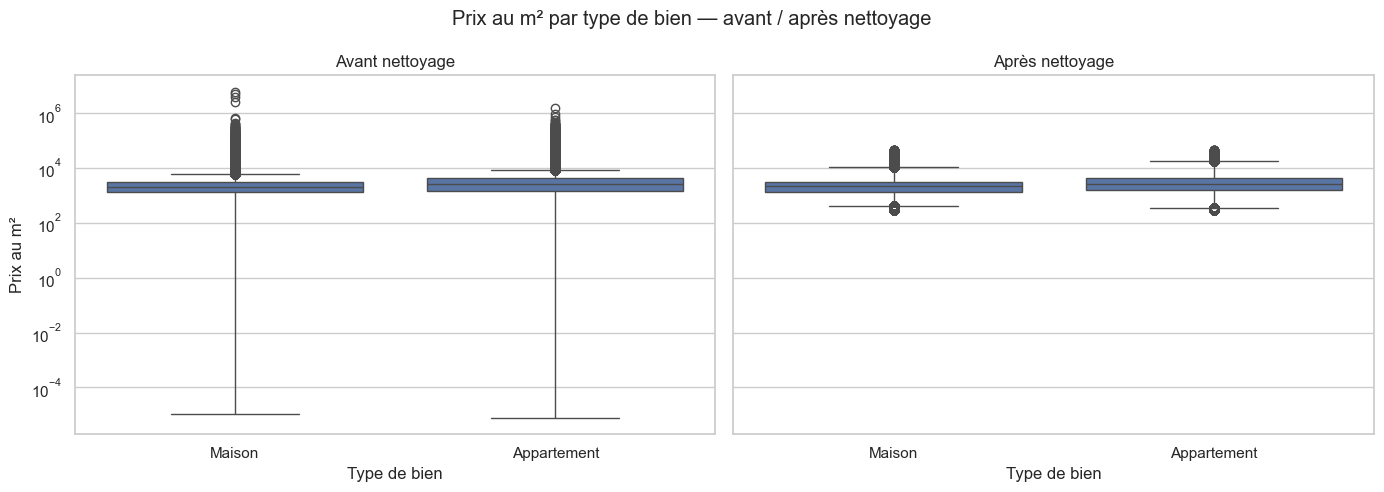

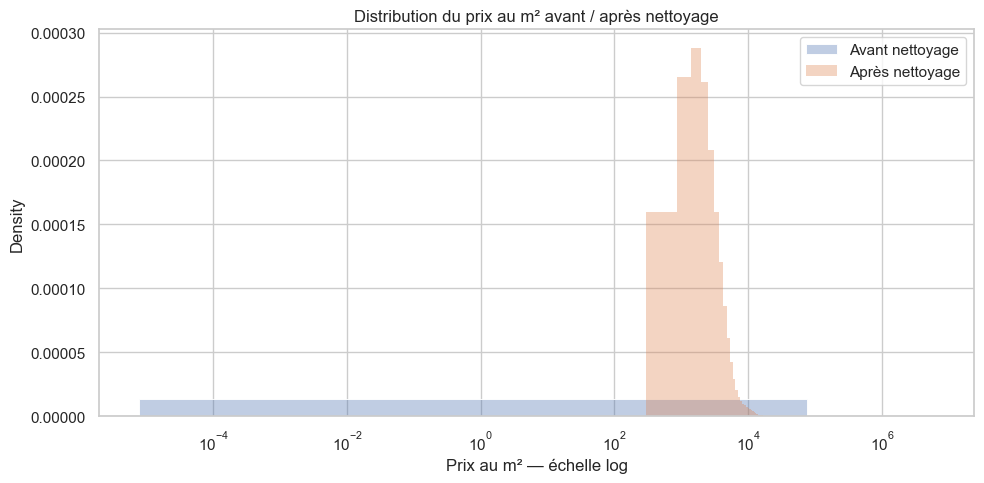

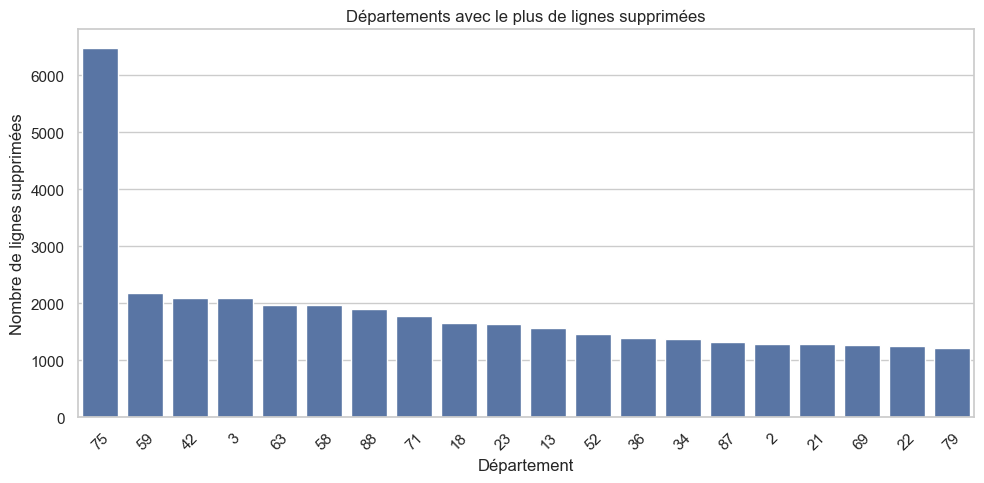

In [ ]:
# Comparaison visuelle avant/après nettoyage
if {"type_bien", "prix_m2"}.issubset(df_res.columns) and {"type_bien", "prix_m2"}.issubset(df_clean.columns):
    # Boîtes à moustaches côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

    sns.boxplot(data=df_res, x="type_bien", y="prix_m2", ax=axes[0])
    axes[0].set_title("Avant nettoyage")
    axes[0].set_yscale("log")
    axes[0].set_xlabel("Type de bien")
    axes[0].set_ylabel("Prix au m²")

    sns.boxplot(data=df_clean, x="type_bien", y="prix_m2", ax=axes[1])
    axes[1].set_title("Après nettoyage")
    axes[1].set_yscale("log")
    axes[1].set_xlabel("Type de bien")
    axes[1].set_ylabel("Prix au m²")

    plt.suptitle("Prix au m² par type de bien — avant / après nettoyage")
    plt.tight_layout()
    plt.show()

# Superposer les histogrammes
if "prix_m2" in df_res.columns and "prix_m2" in df_clean.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_res["prix_m2"].dropna(), bins=80, stat="density", label="Avant nettoyage", alpha=0.35)
    sns.histplot(df_clean["prix_m2"].dropna(), bins=80, stat="density", label="Après nettoyage", alpha=0.35)
    plt.xscale("log")
    plt.xlabel("Prix au m² — échelle log")
    plt.title("Distribution du prix au m² avant / après nettoyage")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Voir où se concentrent les suppressions
geo_col = "code_departement" if "code_departement" in df_deleted.columns else None
if geo_col:
    # Compter les suppressions par département
    deleted_by_geo = (
        df_deleted.groupby(geo_col)
        .size()
        .rename("nb_suppressions")
        .reset_index()
        .sort_values("nb_suppressions", ascending=False)
        .head(20)
    )

    plt.figure(figsize=(10, 5))
    sns.barplot(data=deleted_by_geo, x=geo_col, y="nb_suppressions")
    plt.title("Départements avec le plus de lignes supprimées")
    plt.xlabel("Département")
    plt.ylabel("Nombre de lignes supprimées")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture des visualisations avant / après</h3>
  <div style="color: #4b5563; font-size: 14px;">Les graphiques montrent l’effet attendu du nettoyage : la distribution du prix au m² est resserrée, mais les différences entre maisons et appartements restent visibles. L’échelle logarithmique demeure utile, car les prix immobiliers conservent une dispersion importante même après filtrage.</div>
</div>

In [ ]:
# Vérification que le nettoyage a fonctionné correctement
assert len(df_clean) > 0, "Le dataset nettoyé est vide."

# Vérification que toutes les valeurs sont positives
if "prix_m2" in df_clean.columns:
    assert (df_clean["prix_m2"] > 0).all(), "Des prix au m² non positifs subsistent."

if "surface_reference" in df_clean.columns:
    assert (df_clean["surface_reference"] > 0).all(), "Des surfaces non positives subsistent."

if "valeur_fonciere" in df_clean.columns:
    assert (df_clean["valeur_fonciere"] > 0).all(), "Des valeurs foncières non positives subsistent."

# Vérification de l'absence de valeurs manquantes sur l'identifiant
if "id_mutation" in df_clean.columns:
    assert df_clean["id_mutation"].notna().all(), "Certaines mutations n'ont pas d'identifiant."

checkpoint = pd.DataFrame([
    {"contrôle": "volume final", "valeur": len(df_clean)},
    {"contrôle": "part conservée vs initial", "valeur": len(df_clean) / len(df)},
    {"contrôle": "prix_m2_min", "valeur": df_clean["prix_m2"].min() if "prix_m2" in df_clean.columns else np.nan},
    {"contrôle": "prix_m2_max", "valeur": df_clean["prix_m2"].max() if "prix_m2" in df_clean.columns else np.nan},
])
display(checkpoint)
print("Contrôles de robustesse validés.")

,contrôle,valeur
0,volume final,3.925350e+06
1,part conservée vs initial,9.765570e-01
2,prix_m2_min,3.000000e+02
3,prix_m2_max,4.500000e+04


Contrôles de robustesse validés.


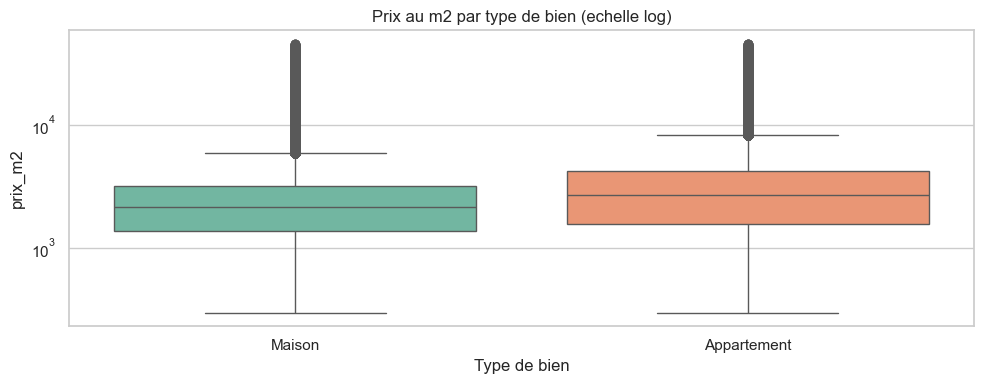

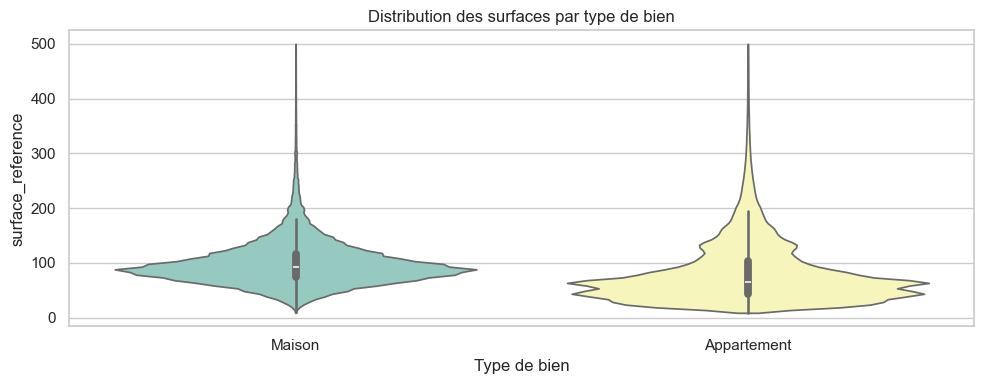

type_bien                 Appartement        Maison
prix_m2           count  1.866845e+06  2.058505e+06
                  mean   3.305331e+03  2.542427e+03
                  std    2.566968e+03  1.852770e+03
                  min    3.000000e+02  3.000000e+02
                  25%    1.569090e+03  1.388670e+03
                  50%    2.681125e+03  2.144767e+03
                  75%    4.206299e+03  3.181818e+03
                  max    4.500000e+04  4.500000e+04
surface_reference count  1.866845e+06  2.058505e+06
                  mean   8.259591e+01  9.966972e+01
                  std    5.976051e+01  4.273099e+01
                  min    9.000000e+00  9.000000e+00
                  25%    4.300000e+01  7.400000e+01
                  50%    6.562000e+01  9.200000e+01
                  75%    1.041000e+02  1.170000e+02
                  max    5.000000e+02  5.000000e+02
valeur_fonciere   count  1.866845e+06  2.058505e+06
                  mean   2.246594e+05  2.462392e+05
                  std    2.321070e+05  2.148234e+05
                  min    2.000000e+04  2.000000e+04
                  25%    1.077400e+05  1.241000e+05
                  50%    1.650000e+05  1.991000e+05
                  75%    2.580000e+05  3.050000e+05
                  max    5.000000e+06  5.000000e+06

In [ ]:
# Analyse des différences entre maisons et appartements
seg_cols = [c for c in ["type_bien", "prix_m2", "surface_reference", "valeur_fonciere"] if c in df_clean.columns]

# Prix au m² comparé par type
if {"type_bien", "prix_m2"}.issubset(df_clean.columns):
    plt.figure(figsize=(10, 4))
    sns.boxplot(data=df_clean, x="type_bien", y="prix_m2", palette="Set2")
    plt.yscale("log")
    plt.title("Prix au m2 par type de bien (echelle log)")
    plt.xlabel("Type de bien")
    plt.ylabel("prix_m2")
    plt.tight_layout()
    plt.show()

# Surfaces comparées par type
if {"type_bien", "surface_reference"}.issubset(df_clean.columns):
    plt.figure(figsize=(10, 4))
    sns.violinplot(data=df_clean, x="type_bien", y="surface_reference", palette="Set3", cut=0)
    plt.title("Distribution des surfaces par type de bien")
    plt.xlabel("Type de bien")
    plt.ylabel("surface_reference")
    plt.tight_layout()
    plt.show()

if seg_cols:
    display(df_clean[seg_cols].groupby("type_bien").describe().T)

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture comparative</h3>
  <div style="color: #4b5563; font-size: 14px;">Les appartements présentent un prix au m² médian plus élevé que les maisons, tandis que les maisons disposent d’une surface médiane plus importante. Cette structure est cohérente avec les marchés résidentiels : les appartements sont plus concentrés en zones urbaines tendues, alors que les maisons couvrent des configurations territoriales et foncières plus variées.</div>
</div>

Part d'ecart > 10% entre prix_m2 et prix_m2_recalcule: 0.00%


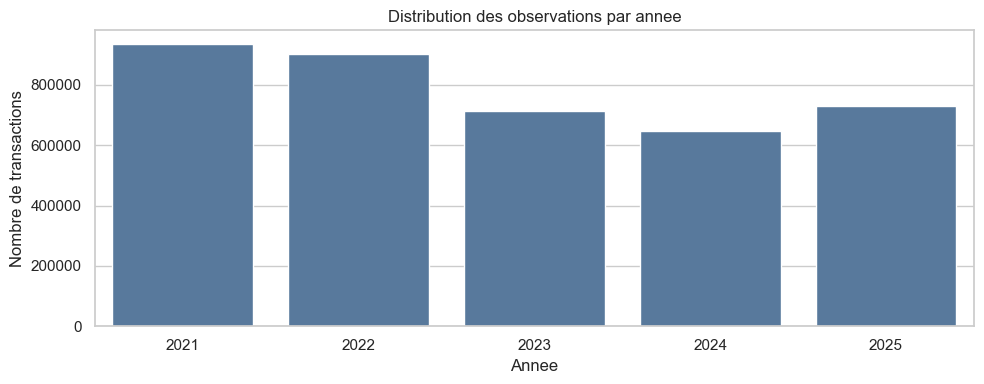

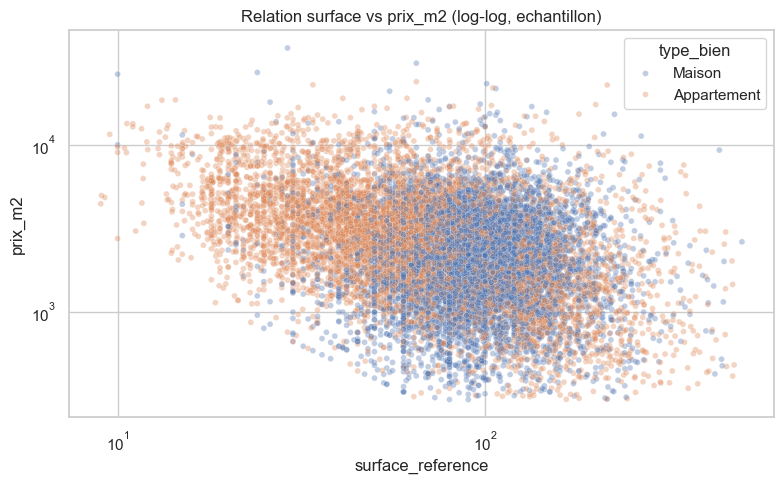

In [ ]:
# Vérification du prix au m² : recalculer et comparaison
if {"valeur_fonciere", "surface_reference"}.issubset(df_clean.columns):
    # Recalculer le prix au m²
    df_clean["prix_m2_recalcule"] = df_clean["valeur_fonciere"] / df_clean["surface_reference"]
    if "prix_m2" in df_clean.columns:
        # Mesurer l'écart
        ecart = (df_clean["prix_m2"] - df_clean["prix_m2_recalcule"]).abs() / df_clean["prix_m2_recalcule"]
        df_clean["flag_ecart_prix_m2_10pct"] = ecart > 0.10
        print("Part d'ecart > 10% entre prix_m2 et prix_m2_recalcule:", f"{df_clean['flag_ecart_prix_m2_10pct'].mean():.2%}")

# Extraire l'année de la date de mutation
if "date_mutation" in df_clean.columns:
    dt = pd.to_datetime(df_clean["date_mutation"], errors="coerce")
    df_clean["annee_mutation"] = dt.dt.year
elif "annee" in df_clean.columns:
    df_clean["annee_mutation"] = pd.to_numeric(df_clean["annee"], errors="coerce")
else:
    df_clean["annee_mutation"] = np.nan

# Voir la distribution temporelle
if "annee_mutation" in df_clean.columns and df_clean["annee_mutation"].notna().any():
    plt.figure(figsize=(10, 4))
    vc = df_clean["annee_mutation"].value_counts(dropna=True).sort_index()
    sns.barplot(x=vc.index.astype(int), y=vc.values, color="#4C78A8")
    plt.title("Distribution des observations par annee")
    plt.xlabel("Annee")
    plt.ylabel("Nombre de transactions")
    plt.tight_layout()
    plt.show()

# Visualiser la relation surface vs prix au m²
if {"surface_reference", "prix_m2", "type_bien"}.issubset(df_clean.columns):
    # Prendre un échantillon pour ne pas surcharger le graphique
    sample = df_clean.sample(min(15000, len(df_clean)), random_state=42)
    plt.figure(figsize=(8, 5))
    sns.scatterplot(
        data=sample,
        x="surface_reference",
        y="prix_m2",
        hue="type_bien",
        alpha=0.35,
        s=18,
    )
    plt.yscale("log")
    plt.xscale("log")
    plt.title("Relation surface vs prix_m2 (log-log, echantillon)")
    plt.tight_layout()
    plt.show()

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Analyse de la relation entre la surface et le prix au m²</h3>
  <div style="color: #4b5563; font-size: 14px;">Le graphique met en évidence une relation décroissante entre la surface et le prix au m² : les petites surfaces présentent généralement des prix unitaires plus élevés. L’utilisation d’une échelle logarithmique améliore la lisibilité des distributions et réduit l’effet des valeurs extrêmes. Les appartements concentrent davantage de biens à prix élevés pour des surfaces réduites, traduisant une forte valorisation des petites surfaces urbaines. Les maisons présentent une dispersion plus importante sur les surfaces élevées, avec des niveaux de prix au m² globalement plus modérés. La variabilité importante observée confirme l’influence conjointe de la localisation, du type de bien et du standing sur la formation des prix immobiliers. Malgré une tendance globale identifiable, la dispersion des points souligne la forte hétérogénéité structurelle du marché résidentiel.</div>
</div>

In [ ]:
# Résumé de  l'impact du nettoyage
summary = {
    "volume_initial": int(len(df)),
    "volume_residentiel": int(len(df[df["flag_residentiel"]])),
    "volume_final_nettoye": int(len(df_clean)),
    "part_finale_vs_initial": float(len(df_clean) / len(df)) if len(df) else np.nan,
}

display(pd.Series(summary, name="valeur").to_frame())
display(impact_df)

# Voir la répartition finale par type
if "type_bien" in df_clean.columns:
    display(df_clean["type_bien"].value_counts(dropna=False).to_frame("n"))

# Sauvegarder la base nettoyée dans le fichier canonique
DATA_PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df_clean.to_parquet(OUTPUT_PATH, index=False)

print("Export réalisé :", OUTPUT_PATH.resolve())

# Statistiques finales sur les variables clés
quality_cols = [c for c in ["valeur_fonciere", "surface_reference", "prix_m2", "prix_m2_recalcule"] if c in df_clean.columns]
if quality_cols:
    display(df_clean[quality_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T)

print("Notebook 2 termine: nettoyage residentiel et preparation analytique finalises.")

,valeur
volume_initial,4.019581e+06
volume_residentiel,4.019581e+06
volume_final_nettoye,3.925350e+06
part_finale_vs_initial,9.765570e-01


,step,n_before,n_after,taux_conserve
0,perimetre_residentiel,4019581,4019581,1.0000
1,exclusion_incoherences_claires,4019581,4017104,0.9994
2,exclusion_outliers_simples,4017104,3925350,0.9772


,n
type_bien,
Maison,2058505
Appartement,1866845


Export réalisé : C:\Users\club_\OneDrive\13_DOCUMENT\SYSTEME_AIDE_DECISION_IMMOBILIERE\data\processed\df_mutations_residentielles_nettoyees.parquet


,count,mean,std,min,1%,5%,50%,95%,99%,max
valeur_fonciere,3925350.0,235976.148226,223470.189993,20000.0,31000.000000,54560.000000,180000.00000,582000.000000,1.105000e+06,5000000.0
surface_reference,3925350.0,91.549639,52.237176,9.0,18.000000,27.750000,83.00000,184.700000,2.808900e+02,500.0
prix_m2,3925350.0,2905.254310,2253.694351,300.0,409.836066,670.004225,2354.83871,6970.588235,1.161964e+04,45000.0
prix_m2_recalcule,3925350.0,2905.254310,2253.694351,300.0,409.836066,670.004225,2354.83871,6970.588235,1.161964e+04,45000.0


Notebook 2 termine: nettoyage residentiel et preparation analytique finalises.


In [19]:
# Bilan final du nettoyage
final_summary = {
    "volume_initial": len(df),
    "volume_final": len(df_clean),
    "lignes_supprimées": len(df) - len(df_clean),
    "part_conservée": len(df_clean) / len(df) if len(df) else np.nan,
    "nb_variables_finales": df_clean.shape[1],
}

display(pd.Series(final_summary, name="valeur").to_frame())

# Comparaison par type de bien
if "type_bien" in df_clean.columns:
    final_type_summary = (
        df_clean.groupby("type_bien")
        .agg(
            nb_lignes=("type_bien", "size"),
            prix_m2_median=("prix_m2", "median"),
            surface_median=("surface_reference", "median"),
        )
        .reset_index()
    )
    display(final_type_summary)

# Lister les limites du nettoyage
limitations = pd.DataFrame([
    {"limite": "Exclusion des extrêmes", "conséquence": "Le dataset final représente mieux le marché résidentiel standard, mais moins les biens atypiques."},
    {"limite": "Absence de qualité du bien", "conséquence": "L'état, les travaux, l'étage ou la vue ne sont pas captés."},
    {"limite": "Périmètre maisons/appartements", "conséquence": "Les terrains et locaux non résidentiels sont volontairement exclus."},
])
display(limitations)

,valeur
volume_initial,4.019581e+06
volume_final,3.925350e+06
lignes_supprimées,9.423100e+04
part_conservée,9.765570e-01
nb_variables_finales,6.200000e+01


,type_bien,nb_lignes,prix_m2_median,surface_median
0,Appartement,1866845,2681.124881,65.62
1,Maison,2058505,2144.767442,92.00


,limite,conséquence
0,Exclusion des extrêmes,Le dataset final représente mieux le marché ré...
1,Absence de qualité du bien,"L'état, les travaux, l'étage ou la vue ne sont..."
2,Périmètre maisons/appartements,Les terrains et locaux non résidentiels sont v...


<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Lecture du bilan final</h3>
  <div style="color: #4b5563; font-size: 14px;">Le bilan confirme un nettoyage maîtrisé : la base finale conserve l’essentiel du volume tout en sécurisant les variables économiques. Les appartements restent plus chers au m², les maisons plus grandes en surface médiane, et les limites listées rappellent que les futurs gains viendront surtout d’enrichissements qualitatifs et territoriaux.</div>
</div>

<div style="background-color: #f8fafc; border: 1px solid #d9e2ec; border-left: 4px solid #1f4e79; border-radius: 6px; padding: 14px 18px; margin: 16px 0; color: #1f2933; font-family: Arial, sans-serif; line-height: 1.55;">
  <h3 style="margin: 0 0 8px 0; color: #1f4e79; font-size: 18px;">Limites et arbitrages méthodologiques</h3>
  <div style="color: #4b5563; font-size: 14px;">Le nettoyage réalisé repose sur une approche progressive fondée sur des seuils métiers immobiliers plutôt que sur des critères statistiques exclusivement automatisés. Certains biens atypiques mais économiquement cohérents peuvent donc subsister volontairement dans le jeu de données afin de préserver la diversité structurelle du marché. Les valeurs manquantes (`NaN`) n’ont pas été systématiquement imputées ou supprimées, leur signification pouvant varier selon les variables : information absente, donnée non applicable ou non collectée. Les traitements ont ainsi été différenciés selon le rôle analytique des variables concernées. Les seuils appliqués constituent des arbitrages méthodologiques visant à limiter les incohérences manifestes sans dégrader excessivement la représentativité territoriale et économique des mutations. Malgré ces contrôles, certaines anomalies résiduelles peuvent persister, notamment sur les transactions atypiques, les dépendances ou certains cas complexes de foncier. Enfin, cette phase de nettoyage a été pensée comme une étape de préparation analytique et non comme une normalisation exhaustive des données. Des ajustements complémentaires pourront être réalisés ultérieurement selon les objectifs de modélisation ou les usages métier retenus.</div>
</div>